# Comprehensive Machine Learning Guide: Evaluation, Bias-Variance, and Hyperparameter Tuning

Welcome to the real engineering part of Machine Learning! This notebook covers four critical components that you MUST know beyond the algorithms themselves:
1. **Errors and Metrics:** How to actually measure success (because accuracy isn't always enough).
2. **The Bias-Variance Tradeoff:** Understanding underfitting vs. overfitting.
3. **Parameters vs. Hyperparameters:** What the model learns vs. what we control.
4. **Hyperparameter Tuning:** Finding the perfect settings systematically instead of guessing.


## 1. Parameters vs. Hyperparameters
- **Parameters:** Internal variables the model learns on its own from the data during training. (e.g., weights `m` and bias `c` in linear regression, threshold splits in a decision tree). You do *not* set these.
- **Hyperparameters:** External configurations set by the *programmer* **before** training begins. (e.g., `K` in KNN, max depth of a decision tree, learning rate in neural networks). They control how the algorithms learn.


## 2. Evaluation / Error Metrics

### Classification Metrics
Used when predicting discrete classes (e.g., Is it a Dog or Cat? Spam or Not Spam? Malignant or Benign?).
- **Confusion Matrix:** A table showing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).
- **Accuracy:** `(TP + TN) / Total`. The percentage of correct predictions. (Dangerous: If 99% of emails are normal and 1% is spam, a model that *always* predicts 'Normal' is 99% accurate, but completely useless!).
- **Precision:** `TP / (TP + FP)`. Out of all the instances the model *predicted* as positive, how many were actually positive? (Crucial when False Positives are costly, like predicting a legit email is Spam).
- **Recall (Sensitivity):** `TP / (TP + FN)`. Out of all the *actual* positive instances, how many did the model find? (Crucial when False Negatives are fatal, like missing a cancer diagnosis).
- **F1-Score:** The harmonic mean of Precision and Recall. Gives you a single score that balances both.

### Regression Metrics
Used when predicting continuous numbers (e.g., House Price, Temperature).
- **MAE (Mean Absolute Error):** The average absolute difference between predicted and actual values.
- **MSE (Mean Squared Error):** The average of the squared differences. Because they are squared, MSE heavily punishes large outliers.
- **RMSE (Root Mean Squared Error):** The square root of MSE. Brings the error back to the original unit (e.g., dollars instead of dollars squared).
- **R-squared (R²):** Score from 0 to 1 representing the proportion of variance in the target variable that's explained by the model. The higher, the better!


## 3. The Bias-Variance Tradeoff
The holy grail of Machine Learning is finding the balance between two sources of error:
- **Bias (Underfitting - "Too Simple"):** The model is ignorant. It makes strong assumptions and misses the underlying pattern in the data entirely. Error is high on both training and test data.
- **Variance (Overfitting - "Too Complex"):** The model is overly sensitive. It memorizes the training data (including the noise) instead of learning the pattern. Error is low on training data, but extremely high on unseen testing data.
- **The Tradeoff:** As you decrease bias (increase model complexity), variance increases, and vice versa. There is a "sweet spot" where total error is minimized.


## 4. Cross-Validation and Hyperparameter Tuning
We never evaluate on the training set. We use a Test set. However, relying on a single train/test split can result in lucky or unlucky testing data.
- **Cross Validation (CV):** To prevent this, we use K-Fold CV. Split the training data into K pieces (folds). Train on K-1 folds, validate on the remaining 1. Repeat K times and average the results for a secure score!

How do we decide the best Hyperparameters (like `K` in KNN)?
- **Grid Search:** Exhaustively test every single possible combination of hyperparameters you give it.
- **Random Search:** Randomly try combinations of hyperparameters over a set number of iterations (much faster for huge models).


---
## 💻 LIVE EXAMPLE IN ACTION

We will use the real **Breast Cancer Dataset** and the **K-Nearest Neighbors (KNN)** algorithm to clearly demonstrate all these concepts.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Imports from scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Setting styling
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


### Loading and Splitting Data
We split our data into Training (used to fit the model) and Testing (locked away safely to evaluate the model later).
Target: 0 = Malignant, 1 = Benign.


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 80/20 train/test split. random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (455, 30)
Testing data shape: (114, 30)


### Demonstrating Bias & Variance (Overfitting vs Underfitting)
Let's see what happens to our performance when we pick terrible values for the `K` hyperparameter.


In [3]:
# 1. OVERFITTING Example (K=1)
# High Variance, Low Bias. The model looks perfectly at its closest 1 neighbor (itself for training data!).
knn_overfit = KNeighborsClassifier(n_neighbors=1)
knn_overfit.fit(X_train, y_train)

train_acc_1 = accuracy_score(y_train, knn_overfit.predict(X_train))
test_acc_1 = accuracy_score(y_test, knn_overfit.predict(X_test))

print(f"K=1   -> Train Accuracy: {train_acc_1:.4f} | Test Accuracy: {test_acc_1:.4f} (Huge gap! It memorized the training data!)")

# 2. UNDERFITTING Example (K=300)
# High Bias, Low Variance. The model looks at 300 neighbors, creating a super vague, simple boundary.
knn_underfit = KNeighborsClassifier(n_neighbors=300)
knn_underfit.fit(X_train, y_train)

train_acc_300 = accuracy_score(y_train, knn_underfit.predict(X_train))
test_acc_300 = accuracy_score(y_test, knn_underfit.predict(X_test))

print(f"K=300 -> Train Accuracy: {train_acc_300:.4f} | Test Accuracy: {test_acc_300:.4f} (Both scores are dragged down. Too simple!)")


K=1   -> Train Accuracy: 1.0000 | Test Accuracy: 0.9298 (Huge gap! It memorized the training data!)
K=300 -> Train Accuracy: 0.8044 | Test Accuracy: 0.8070 (Both scores are dragged down. Too simple!)


### Visualizing the Tradeoff Curve
A picture is worth a thousand words. Let's actually plot the train and test errors across many values of K to see the tradeoff curve!


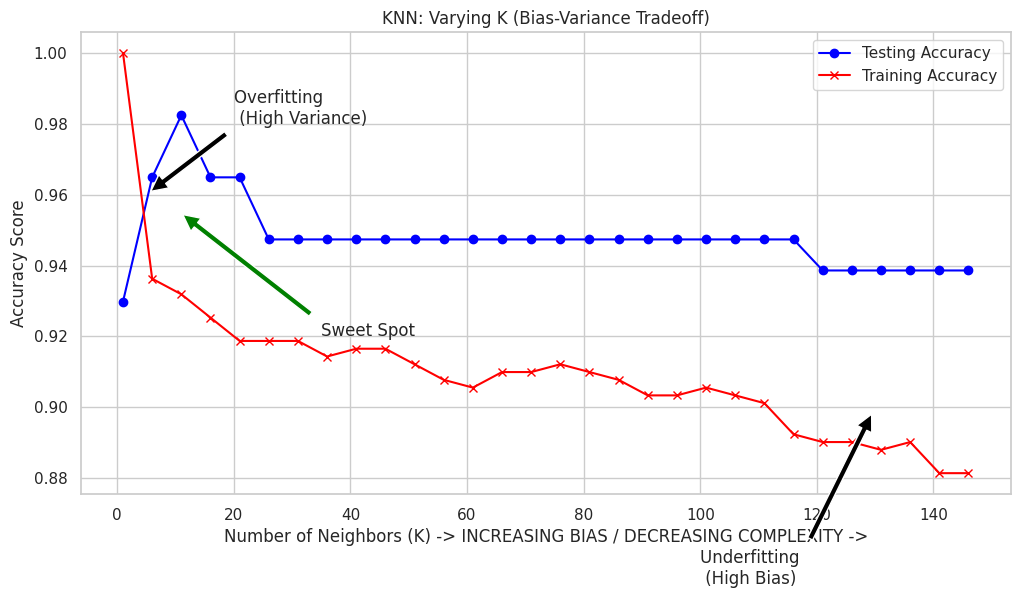

In [4]:
neighbors = np.arange(1, 150, 5) # Test every 5th neighbor from 1 to 150
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i, k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_accuracy[i] = knn.score(X_train, y_train)
    test_accuracy[i] = knn.score(X_test, y_test)

plt.figure(figsize=(12, 6))
plt.title('KNN: Varying K (Bias-Variance Tradeoff)')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy', color='blue', marker='o')
plt.plot(neighbors, train_accuracy, label='Training Accuracy', color='red', marker='x')

plt.xlabel('Number of Neighbors (K) -> INCREASING BIAS / DECREASING COMPLEXITY ->')
plt.ylabel('Accuracy Score')
plt.legend()
plt.annotate('Overfitting \n (High Variance)', xy=(5, 0.96), xytext=(20, 0.98), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Underfitting \n (High Bias)', xy=(130, 0.90), xytext=(100, 0.85), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Sweet Spot', xy=(10, 0.956), xytext=(35, 0.92), arrowprops=dict(facecolor='green', shrink=0.05))
plt.show()


### Hyperparameter Tuning (GridSearchCV)
Instead of visually scanning plots, let's automate finding the perfect hyperparameters using Cross Validation and Grid Search!


In [8]:
# Step 1: Define a dictionary of the hyperparameters you want to try
param_grid = {
    'n_neighbors': np.arange(1, 30), # Test K from 1 to 29
    'weights': ['uniform', 'distance'], # Should close neighbors count more than distant ones?
    'metric': ['euclidean', 'manhattan'] # How should we measure distance?
}

# Step 2: Initialize base model
knn_base = KNeighborsClassifier()

# Step 3: Set up GridSearchCV (cv=5 means 5-Fold Cross Validation for each combination)
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Step 4: FIT to training data. (This handles testing all combinations internally)
grid_search.fit(X_train, y_train)

print(f"Optimal Hyperparameters Found: {grid_search.best_params_}")
print(f"Best CV Average Accuracy:      {grid_search.best_score_:.4f}")


Optimal Hyperparameters Found: {'metric': 'manhattan', 'n_neighbors': np.int64(6), 'weights': 'uniform'}
Best CV Average Accuracy:      0.9407


### Extracting the Final Model & Deep Evaluation
Now we take our absolute best model and unleash it on the completely unseen Test Data. Let's look at the deep metrics.


In [10]:
# Extract the tuned model
tuned_knn = grid_search.best_estimator_

# Final Predictions
y_pred = tuned_knn.predict(X_test)

print("--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")


--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

   Malignant       0.97      0.91      0.94        43
      Benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy:  0.9561
Precision: 0.9459
Recall:    0.9859
F1-Score:  0.9655


### The Confusion Matrix
A visual representation to see EXACTLY what our model gets right and the exact mistakes it made on False Positives and False Negatives.


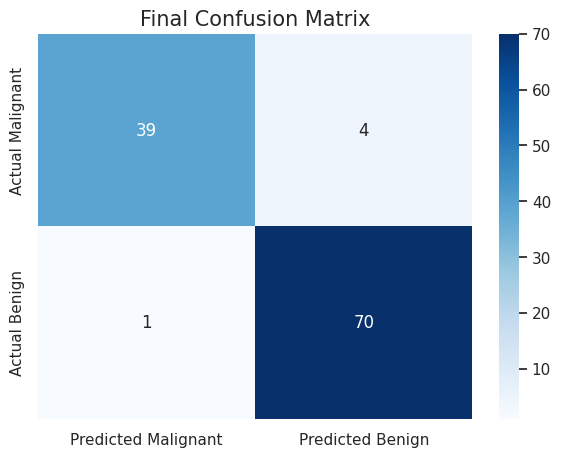

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))

# Creating a heatmap for the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Malignant', 'Predicted Benign'], 
            yticklabels=['Actual Malignant', 'Actual Benign'])

plt.title('Final Confusion Matrix', size=15)
plt.show()

# What does this mean? 
# Top Left: True Negatives (Malignant guessed as Malignant)
# Bottom Right: True Positives (Benign guessed as Benign)
# Bottom Left: False Negatives (Benign guessed as Malignant - Model was too cautious)
# Top Right: False Positives (Malignant guessed as Benign - HIGHLY DANGEROUS IN CANCER DETECTION)
